In [ ]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import warnings
from tqdm.auto import trange

In [ ]:
%load_ext tensorboard

This lab focuses on algorithm called MAML. Make sure you understand all concepts related to it before you start the exercise.

Link to the paper: https://arxiv.org/abs/1703.03400

# Supervised MAML

In the first part of the lab you will implement missing pieces of supervised MAML training pipeline, train a meta policy and evaluate it.



## Dataset and network definition

You are provieded a meta-learning dataset class that supports two low resolution image datasets: omniglot and mnist. For the sake of limited time we suggest you use mnist to test your solution first.

In order to train MAML we need a special network definition that allows using weights provided with the sample. Checkout the current implementation of the network.

In [ ]:
class NWayKShotDataset:
    QUERY_SIZE = 1

    def __init__(self, N, K, dataset_name="omniglot", prepare_test_samples=True):
        self.N = N
        self.K = K
        self.prepare_test_samples = prepare_test_samples
        assert dataset_name in ["omniglot", "mnist"], "dataset not supported"

        ds = tfds.load(dataset_name, split="train+test", as_supervised=True)

        @tf.function()
        def preprocess_img(i, l):
            if dataset_name == "omniglot":
                i = tf.image.rgb_to_grayscale(i)
                i = tf.image.resize(i, [28, 28])
            i = tf.cast(i, float)
            i = i / 256
            return i, l

        ds = ds.map(preprocess_img).cache()

        images = np.array([s[0] for s in ds.as_numpy_iterator()])
        labels = np.array([s[1] for s in ds.as_numpy_iterator()])

        if self.prepare_test_samples:
            num_train_labels = self._get_num_train_labels
            self.train_labels = np.random.choice(
                np.unique(labels), size=num_train_labels, replace=False
            )
            test_index = np.ones(len(np.unique(labels)))
            test_index[self.train_labels] = 0
            self.test_labels = np.arange(len(np.unique(labels)))[test_index.astype(bool)]
        else:
            self.train_labels = np.unique(labels)

        if not all(
            [
                len(images[labels == l]) >= self.K + self.QUERY_SIZE
                for l in np.unique(labels)
            ]
        ):
            raise AttributeError(
                f"Not enough datapoints to do {self.K}-shot classification."
            )

        self.images_per_label = dict()
        for l in np.unique(labels):
            self.images_per_label[l] = images[labels == l]

    def _get_num_train_labels(self, dataset_name, num_labels):
        if dataset_name == "omniglot":
            return 1200
        else:
            return int(num_labels * 2 / 3)

    def get_sample(self, available_tasks):
        tasks = np.random.choice(available_tasks, size=self.N, replace=False)
        images = [
            self.images_per_label[task][
                np.random.choice(
                    np.arange(len(self.images_per_label[task])),
                    self.K + self.QUERY_SIZE,
                )
            ]
            for task in tasks
        ]

        # Train labels are adjusted per each task (original symbol labels are discarded)
        train_labels = np.repeat(np.arange(self.N), self.K).reshape(-1)
        train_images = np.concatenate([imgs[: self.K] for imgs in images])
        query_labels = np.repeat(np.arange(self.N), self.QUERY_SIZE).reshape(-1)
        query_images = np.concatenate([imgs[-self.QUERY_SIZE :] for imgs in images])

        return train_images, train_labels, query_images, query_labels

    def get_train_sample(self):
        return self.get_sample(self.train_labels)

    def get_test_sample(self):
        if not self.prepare_test_samples:
            warnings.warn("Test samples not prepared. Returning train sample")
            return self.get_train_sample()
        return self.get_sample(self.test_labels)


In [ ]:
class MLP(tf.keras.Model):
    def __init__(self, input_size, hidden_sizes, output_size):
        super().__init__()

        self.vars = {}
        self.order = []
        weight_initializer = tf.keras.initializers.GlorotUniform()
        for i, (s1, s2) in enumerate(zip([input_size] + hidden_sizes, hidden_sizes + [output_size])):
            w = tf.Variable(weight_initializer([s1, s2]))
            b = tf.Variable(tf.zeros(s2))
            self.vars[f"{i}:bias"] = b
            self.vars[f"{i}:weights"] = w
            self.order.append(str(i))

    def call(self, x, vars=None):
        if vars is None:
            vars = self.vars

        for name in self.order:
            w = vars[f"{name}:weights"]
            b = vars[f"{name}:bias"]
            x = tf.matmul(x, w)
            x = x + b

        return x

### Addtional (optional) exercise
Extend the definition of a  network. Implement new layer types: batch norm, conv layers, etc.

## Know your data

Each training sample contains of 4 elements: train_images, train_labels, query_images, query_labels.

Use visualization code below, modify it to your needs, make sure you understand the dataset (if needed checkout the implementation of dataset above).

local data directory. If you'd instead prefer to read directly from our public
GCS bucket (recommended if you're running on GCP), you can instead pass
`try_gcs=True` to `tfds.load` or set `data_dir=gs://tfds-data/datasets`.



Dl Completed...:   0%|          | 0/4 [00:00<?, ? file/s]


Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


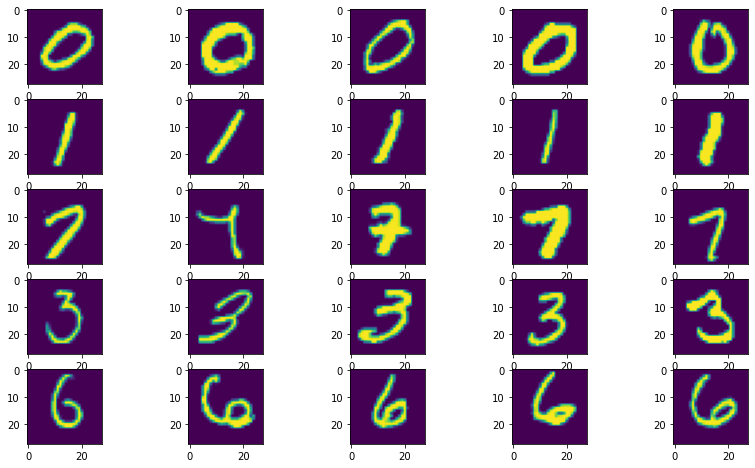

In [ ]:
dset_name="mnist"
dataset = NWayKShotDataset(N=5, K=5, dataset_name=dset_name, prepare_test_samples=False)
train_images, train_labels, query_images, query_labels = dataset.get_train_sample()
nr = dataset.N
nc = dataset.K
plt.subplots(nr, nc, figsize=(14,8))
for i, img in enumerate(train_images):
    plt.subplot(nr, nc, i+1)
    plt.imshow(img[..., 0])

## MAML implementation

In [ ]:
%tensorboard --logdir logs

### Training loop
Finnish the implementation of MAML and train the network. You should be able to easily reach 90% accuracy.

In [ ]:
## HYPER PARAMS ##
hidden = [256, 128, 64]
outer_lr = 3e-4
inner_lr = 3e-3
batch_size = 8
##################

model = MLP(28 * 28, hidden, 5)
optimizer = tf.keras.optimizers.Adam(learning_rate=outer_lr)

current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
train_log_dir = f'logs/{dset_name}/'+ f"{hidden}_olr={outer_lr}_ilr={inner_lr}_bs={batch_size}/" + current_time
train_summary_writer = tf.summary.create_file_writer(train_log_dir)

for e in trange(10_000 // batch_size):
    # Sample batch of tasks
    batch = [dataset.get_train_sample() for _ in range(batch_size)]
    train_losses = []
    query_losses = []
    q_preds = []
    q_labels = []
    with tf.GradientTape(persistent=True) as tape:
        for train_images, train_labels, query_images, query_labels in batch:
            # Compute inner training loss
            pred = model(tf.reshape(train_images, (train_images.shape[0], -1)))
            train_loss = tf.nn.sparse_softmax_cross_entropy_with_logits(train_labels, pred)

            ## Compute inner gradients
            grads = tape.gradient(train_loss, list(model.vars.values()))

            # TODO Compute new weights (using sgd update rule)
            new_weights = ["TODO" for w, g in zip(model.vars.values(), grads)]
            # Prepare model variable dictionary with new weights)
            new_vars = {k: v for k, v in zip(model.vars.keys(), new_weights)}

            # TODO Compute query loss
            query_pred = ...
            query_loss = ...

            # Store metrics
            train_losses.append(train_loss)
            query_losses.append(query_loss)
            q_preds.append(query_pred)
            q_labels.append(query_labels)

    ## TODO compute query gradient and apply it to the proper variables
    grads = ...
    optimizer.apply_gradients("TODO")

    # Log data to tensorboard
    q_preds = tf.concat(q_preds, axis=0)
    q_labels = tf.concat(q_labels, axis=0)
    accuracy = tf.reduce_mean(tf.cast(tf.argmax(q_preds, axis=-1) == q_labels, float))
    with train_summary_writer.as_default():
        tf.summary.scalar('train_loss', tf.reduce_mean(train_losses), step=e * batch_size)
        tf.summary.scalar('query_loss', tf.reduce_mean(query_losses), step=e * batch_size)
        tf.summary.scalar('accuracy', accuracy, step=e * batch_size)


  0%|          | 0/1250 [00:00<?, ?it/s]

## Test your solution

In [ ]:
# Finnish implementation of adaptation phase below and visualize predictions using script provided in next cell.
train_images, train_labels, query_images, query_labels = dataset.get_train_sample()
with tf.GradientTape(persistent=True) as tape:
    pred = model(tf.reshape(train_images, (train_images.shape[0], -1)))
    with tape.stop_recording():
        query_pred_before_update = model(tf.reshape(query_images, (query_images.shape[0], -1)))

    # TODO Compute train loss, train gradients, new weights and query prediction
    query_pred = model("TODO")

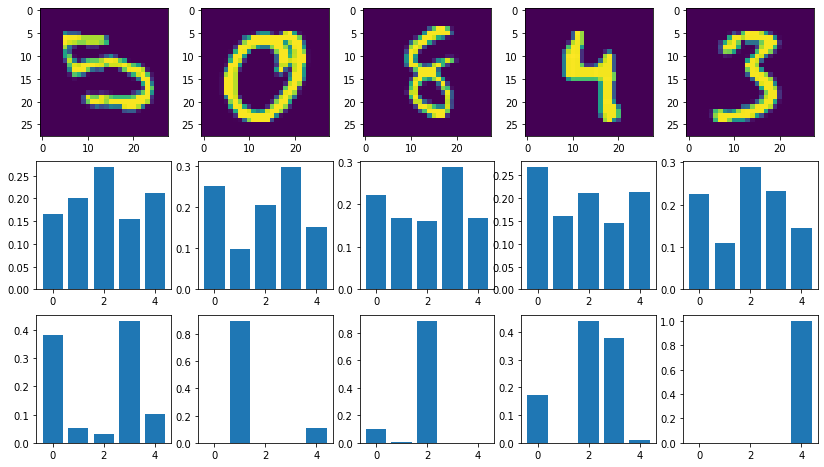

In [ ]:
nr = 3
nc = 5
plt.subplots(nr, nc, figsize=(14,8))
for i, img in enumerate(query_images):
    plt.subplot(nr, nc, i+1)
    plt.imshow(img[..., 0])
    plt.subplot(nr, nc, i + nc + 1)
    plt.bar(np.arange(dataset.N), tf.nn.softmax(query_pred_before_update[i]))
    plt.subplot(nr, nc, i + 2*nc + 1)
    plt.bar(np.arange(dataset.N), tf.nn.softmax(query_pred[i]))

# RL MAML

The second part of the exercise is related to RL version of MAML.

Due to limited resources. You will be only asked to adapt the trained model using prepared code and evaluate the results.

The templates heavily rely on the implementation of MAML RL from https://github.com/MoritzTaylor/maml-rl-tf2.
Be sure to investiage the repository and run your own experiments.



## Setup

In [ ]:
!git clone https://github.com/MoritzTaylor/maml-rl-tf2.git
!wget https://students.mimuw.edu.pl/~mo382777/rl-course/baseline-100.data-00000-of-00001
!wget https://students.mimuw.edu.pl/~mo382777/rl-course/baseline-100.index
!wget https://students.mimuw.edu.pl/~mo382777/rl-course/policy-100.data-00000-of-00001
!wget https://students.mimuw.edu.pl/~mo382777/rl-course/policy-100.index

In [ ]:
import os
import sys
sys.path.append("maml-rl-tf2")

import numpy as np
import matplotlib.pyplot as plt
import cv2
import imageio
import tensorflow as tf
import gym
from gym import spaces
from gym.utils import seeding
from gym.envs.registration import register

from maml_rl.policies.normal_mlp import NormalMLPPolicy
from maml_rl.baselines.linear_baseline import LinearFeatureBaseline
from maml_rl.sampler import BatchSampler
from maml_rl.metalearners.maml_trpo import MetaLearner

## Environment definition

You will test the MAML solution on 2DNavigation task. Player is placed on 2d plane and has to navigate to a specified goal.
Since you are training a meta learning algorithm MAML will be presented multiple instances of this env where the goal is in a different place each time.

The environment state can be rendered as an image:
* the green dot is a goal
* the black dot is a player
* the red rings are just helper lines for better orientation (they are drawn at constant distance from the center of the plane)

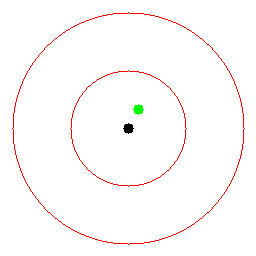

In [ ]:
class Navigation2DEnv(gym.Env):
    """2D navigation problems, as described in [1]. The code is adapted from
    https://github.com/cbfinn/maml_rl/blob/9c8e2ebd741cb0c7b8bf2d040c4caeeb8e06cc95/maml_examples/point_env_randgoal.py

    At each time step, the 2D agent takes an action (its velocity, clipped in
    [-0.1, 0.1]), and receives a penalty equal to its L2 distance to the goal
    position (ie. the reward is `-distance`). The 2D navigation tasks are
    generated by sampling goal positions from the uniform distribution
    on [-0.5, 0.5]^2.

    [1] Chelsea Finn, Pieter Abbeel, Sergey Levine, "Model-Agnostic
        Meta-Learning for Fast Adaptation of Deep Networks", 2017
        (https://arxiv.org/abs/1703.03400)
    """
    def __init__(self, task={}):
        super(Navigation2DEnv, self).__init__()

        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
            shape=(2,), dtype=np.float32)
        self.action_space = spaces.Box(low=-0.1, high=0.1,
            shape=(2,), dtype=np.float32)

        self._task = task
        self._goal = task.get('goal', np.zeros(2, dtype=np.float32))
        self._state = np.zeros(2, dtype=np.float32)
        self.seed()

    def seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def sample_tasks(self, num_tasks):
        goals = self.np_random.uniform(-0.5, 0.5, size=(num_tasks, 2))
        tasks = [{'goal': goal} for goal in goals]
        return tasks

    def reset_task(self, task):
        self._task = task
        self._goal = task['goal']

    def reset(self, env=True):
        self._state = np.zeros(2, dtype=np.float32)
        return self._state

    def step(self, action):
        action = np.clip(action, -0.1, 0.1)
        assert self.action_space.contains(action), f"Action {action} not in the action space"
        self._state = self._state + action

        x = self._state[0] - self._goal[0]
        y = self._state[1] - self._goal[1]
        reward = -np.sqrt(x ** 2 + y ** 2)
        done = ((np.abs(x) < 0.01) and (np.abs(y) < 0.01))

        return self._state, reward, done, self._task

    def render(self, *args, **kwargs):
        plane = np.ones((256, 256, 3)) * 255
        scale = plane.shape[0]
        dist = max([np.max(np.abs(self._goal)), np.max(np.abs(self._state)), 0.5]) * 1.1

        plane = cv2.circle(img=plane, center=(scale // 2, scale // 2), radius=int(0.25/ dist/ 2 * scale), color=(255, 0, 0), thickness=1)
        plane = cv2.circle(img=plane, center=(scale // 2, scale // 2), radius=int(0.5/ dist/ 2 * scale), color=(255, 0, 0), thickness=1)


        plane = cv2.circle(img=plane, center=tuple(((dist - self._goal) / 2 / dist * scale).astype(int)), radius=5, color=(0, 255, 0), thickness=-1)
        plane = cv2.circle(img=plane, center=tuple(((dist - self._state) / 2 / dist * scale).astype(int)), radius=5, color=(0, 0, 0), thickness=-1)

        return plane.astype(np.uint8)

register(
    'My2DNavigation-v0',
    entry_point='__main__:Navigation2DEnv',
    max_episode_steps=100
)

## Prepare policy

We use pretrained policy since training takes few hours.

In [ ]:
env = gym.make('My2DNavigation-v0')
def load_meta_learner_params(policy_path, baseline_path, env):

    with tf.name_scope('policy') as scope:
        policy = NormalMLPPolicy(
            int(np.prod(env.observation_space.shape)),
            int(np.prod(env.action_space.shape)),
            hidden_sizes=(100, 100, 100),
            name=scope
        )
    policy.load_weights(policy_path)

    baseline = LinearFeatureBaseline(int(np.prod(env.observation_space.shape)))
    baseline.load_weights(baseline_path)

    return policy, baseline

policy, baseline = load_meta_learner_params("policy-100", "baseline-100", env)


## Define test and visualization functions

In [ ]:
def get_action(policy, obs):
    with tf.device('cpu:0'):
        obs_tensor = tf.convert_to_tensor(obs[np.newaxis], dtype=tf.float32)

    action_tensor = policy(obs_tensor, params=None).sample()

    with tf.device('cpu:0'):
        action = action_tensor.numpy()
    return action[0]

def test_policy(policy, env, num_test_episodes):
    sum_rew = 0
    for _ in range(num_test_episodes):
        done = False
        obs = env.reset()
        while not done:
            action = get_action(policy, obs)
            obs, rew, done, _ = env.step(action)
            sum_rew += rew

    return sum_rew / num_test_episodes

def visualize_policy(policy, env, gif_name):
    obs = env.reset()
    done = False
    with imageio.get_writer(gif_name, mode='I', fps=5) as writer:
        while not done:
            writer.append_data(env.render())
            action = get_action(policy, obs)
            obs, _, done, _ = env.step(action)

        writer.append_data(env.render())
        # Add black screen at the end
        for _ in range(10):
            writer.append_data(np.zeros((256, 256, 3), dtype=np.uint8))

## Run the evaluation

Observe policy before and after adaptation. How would you describe the behaviour of unadapted policy?

Test different parameters of adaptation procedure (batch_size, learning rate, number of steps) see how they influence the results.

In [ ]:
sampler = BatchSampler(env_name='My2DNavigation-v0', batch_size=40, num_workers=2)
task = env.sample_tasks(1)[0]
sampler.reset_task(task)
env.reset_task(task)

num_test_episodes = 40

avg_rew = test_policy(policy, env, num_test_episodes)
print(f"step=0 avg_rew={avg_rew}")
visualize_policy(policy, env, "step0.gif")

for step in range(1, 4):
    if step == 1:
        learner = MetaLearner(sampler, policy, baseline, optimizer=None, fast_lr=0.1)
    else:
        learner = MetaLearner(sampler, policy, baseline, optimizer=None, fast_lr=0.05)

    episodes = sampler.sample(learner.policy)
    new_params = learner.adapt(episodes)
    learner.policy.set_params_with_name(new_params)

    avg_rew = test_policy(learner.policy, env, num_test_episodes)
    print(f"step={step} avg_rew={avg_rew}")
    visualize_policy(learner.policy, env, f"step{step}.gif")

### Additional (optional) exercise
Think how would you adjust the learner class (located in `maml-rl-tf2/maml_rl/metalearners/maml_trpo.py`) to use PPO update rule instead of TRPO update rule. Try to implement the changes and run training using `maml-rl-tf2/main.py` file.


